## 005 - AppleCider multimodal
<a id='index'></a> <br>

- [part 0: config](#config)
- [part 1: DataGenerator](#data)
    - [photometry, metadata, images, spectra (there are plots <3)](#stuff)
- [part 2: DataLoader](#dataload)
<a id='data'></a>

In [1]:
import os
import sys
sys.path.insert(0, '/Users/junell/Documents/AppleCider')

import joblib
import torch
from torch.utils.data import Dataset
import numpy as np
import pandas as pd

from scipy.interpolate import interp1d
from scipy import stats
from datetime import datetime
import wandb

from AppleCider.preprocess.data_preprocessor import AlertProcessor, PhotometryProcessor, DataPreprocessor, SpectraProcessor
from AppleCider.preprocess.data_preprocessor import DataSorter
from AppleCider.preprocess.transient_dataset import TransientDataset
import AppleCider.preprocess.plot_data as plot_data

from AppleCider.core.model import Informer
from AppleCider.core.trainer import Trainer

import AppleCider.core.tune as tune 
from AppleCider.core.dataset import DataGenerator

import pickle
from torch.utils.data import DataLoader
from torch import nn


from datetime import datetime
import optuna 
from optuna.exceptions import DuplicatedStudyError

#from sklearn.model_selection import train_test_split

In [2]:
CLASSES = ['SN Ia', 'SN II', 'SN IIP', 'Cataclysmic', 'AGN', 'SN IIn', 'SN Ic', 'SN Ib', 'SN IIb', 'Tidal Disruption Event']
data_dir = '/Users/junell/Documents/AppleCider_Data/SEDM_folder'

data_test = pd.read_csv('/Users/junell/Documents/AppleCider/data_test.csv')
data_train = pd.read_csv('/Users/junell/Documents/AppleCider/data_train.csv')

SEDM_dataset = pd.read_csv('/Users/junell/Documents/AppleCider/SEDM_dataset.csv')

In [3]:
## obj_id, type for every object with SEDM spectra
SEDM_dataset[:2]

,obj_id,type
0,ZTF18aatfxtd,SN Ia
1,ZTF18aawppyt,SN Ia


In [4]:
## obj_id, alert file name, type
data_train[:2]

,name,file,type
0,ZTF17aaajnki,ZTF17aaajnki_alert_2.npy,AGN
1,ZTF17aaaukqn,ZTF17aaaukqn_alert_10.npy,Cataclysmic


In [5]:
print(len(data_train))
print(len(data_test))

9635
1878


<big>part 0: config</big>

<a id='config'></a>

<u>what paths / files do i need?</u>
- stuff you just need:
    - `SEDM_folder` which you can get from Google Drive, link in the README of repo <3
- stuff you can get from the data pre-processing steps:
    - data_train.csv (`df_path`) created in `001-data-processing.ipynb`. <small>(included in the repo) </small>
    - preprocessed data (`preprocessed_path`) <small>not in repo but i'll upload to github (lmk if this link doesn't work)</small>
    - train_files.pkl (`train_files_path`) & val_files.pkl (`val_files_path`) created in `001-data-processing.ipynb`. <small>(included in the repo) </small>
    - scaler.pkl (`scaler_path`) created in `003-AppleCider-metadata.ipynb`. <small>(included in the repo) </small>
    
<i><small>[back to index](#index)</small></i>

In [6]:
config = {
        'project': 'AppleCider',
        'mode': 'all',    # 'clip' 'photo' 'spectra' 'meta' 'image' 'all'
        'config_from': None,    # 'meridk/AstroCLIPResults/d2u52yml',
        'random_seed': 42,  # 42, 66, 0, 12, 123
        'use_wandb': True,
        'save_weights': False,
        'weights_path': f'AppleCider/weights/{datetime.now().strftime("%Y-%m-%d-%H-%M")}',
        'use_pretrain': None,
        'freeze': False,

        # Data General
        'preprocessed_path':'/Users/junell/Documents/AppleCider_Data/data_train/',
        'df_path': '/Users/junell/Documents/AppleCider/data_train.csv',
        
        # save train, val file names ...
        'train_files_path': '/Users/junell/Documents/AppleCider/train_files.pkl',
        'val_files_path': '/Users/junell/Documents/AppleCider/val_files.pkl',
        
        'step': 'type',
        'classes': CLASSES,
        'group_labels': True,
        'max_samples': 5000,
        'num_classes': len(CLASSES),

        # Photometry Model
        'seq_len': 180,
        'p_enc_in': 4,
        'p_d_model': 128,
        'p_dropout': 0.2,
        'p_factor': 1,
        'p_output_attention': False,
        'p_n_heads': 4,
        'p_d_ff': 512,
        'p_activation': 'gelu',
        'p_e_layers': 8,

        # Spectra Model
        's_dropout': 0.2,
        's_conv_channels': [1, 64, 64, 32, 32],
        's_kernel_size': 3,
        's_mp_kernel_size': 4,

        # Metadata Model
        'm_hidden_dim': 256,
        'm_dropout': 0.2,
        # TODO use actual column names
        'meta_cols': range(10),
        'scaler_path': '/Users/junell/Documents/AppleCider/core/scaler.pkl',

        # Image Model
        'input_channels': 3,
        'conv1_channels': 64,
        'conv2_channels': 16,
        'conv_kernel': 3,
        'conv_dropout1': 0.45,
        'conv_dropout2': 0.65,

        # MultiModal Model
        'hidden_dim': 128,
        'fusion': 'avg',  # 'avg', 'concat'

        # Training
        'batch_size': 512,
        'lr': 0.001,
        'beta1': 0.9,
        'beta2': 0.999,
        'weight_decay': 0.01,
        'epochs': 100,
        'early_stopping_patience': 6,
        'scheduler': 'ReduceLROnPlateau',  # 'ExponentialLR', 'ReduceLROnPlateau'
        'gamma': 0.9,  # for ExponentialLR scheduler
        'factor': 0.3,  # for ReduceLROnPlateau scheduler
        'patience': 3,  # for ReduceLROnPlateau scheduler
        'warmup': False,
        'warmup_epochs': 10,
        'clip_grad': False,
        'clip_value': 5
    }


In [7]:
wandb.init(
    project=config['project'],
    config=config, group='AC',
    job_type='train')

wandb: Currently logged in as: ajunell (ajunell-university-of-minnesota) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
/Users/junell/opt/anaconda3/lib/python3.8/site-packages/pydantic/main.py:314: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(
/Users/junell/opt/anaconda3/lib/python3.8/site-packages/pydantic/main.py:314: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


<a id='Dataset'></a> <br>

<br>

<big>part 1: Dataset</big>
<a id='stuff'></a>

***

<i><small>[back to index](#index)</small></i>

In [8]:
train_dataset = DataGenerator(config=config, split='train')
val_dataset = DataGenerator(config=config, split='val')

In [9]:
obj_id = 'ZTF17aaaukqn'
print(f"ex photometry for {obj_id}:")
photometry = train_dataset[2][0][:13]
photometry

ex photometry for ZTF17aaaukqn:


tensor([[ 0.0000,  1.2316, -0.9936,  0.0000],
        [ 0.0271, -0.9892,  1.1610,  0.0000],
        [ 0.9740, -0.9892,  1.1349,  0.0000],
        [ 1.0020,  1.2712, -0.9936,  0.0000],
        [ 1.9847, -0.9892,  0.8568,  0.0000],
        [ 1.9918,  0.9386, -0.9936,  0.0000],
        [ 2.9745, -0.9892,  1.0266,  0.0000],
        [ 3.0138,  0.7160, -0.9936,  0.0000],
        [ 3.9790, -0.9892,  1.0697,  0.0000],
        [ 4.0045,  0.9934, -0.9936,  0.0000],
        [ 5.0076,  0.7844, -0.9936,  0.0000],
        [ 5.0181, -0.9892,  0.7128,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000]])

the photometry is only from one of the alerts, so it only goes to 5 days unlike the original (but still cut to 10 days) photometry

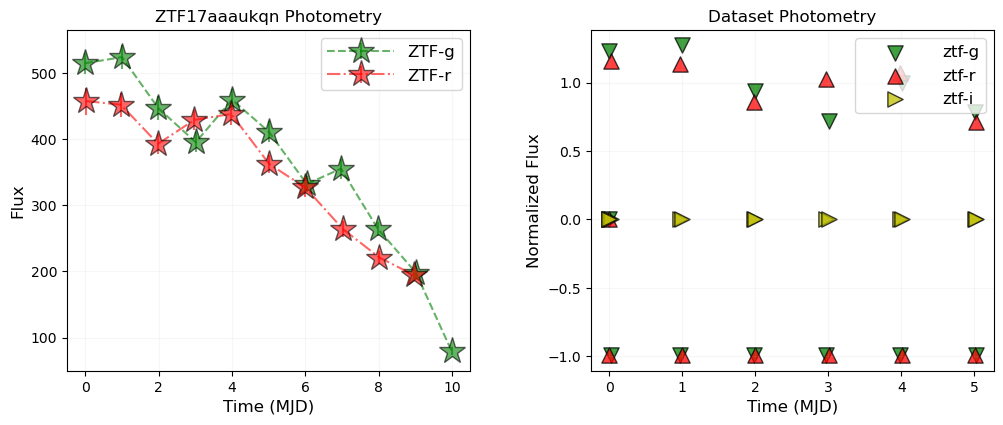

In [10]:
plot_data.compare_tensor_photometry(photometry, obj_id, SEDM_dataset, data_dir)

In [11]:
obj_id = 'ZTF17aaaukqn'
print(f"ex metadata for {obj_id}:")
print("sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky")
metadata = train_dataset[2][2]
metadata

ex metadata for ZTF17aaaukqn:
sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky


tensor([-0.8228, -1.1063, -1.0853, -1.4154, -1.2455,  1.2171, -1.5126, -0.9482,
         0.6302, -0.0748])

In [12]:
obj_id = 'ZTF17aaaukqn'
print(f"ex images for {obj_id}:")
images = train_dataset[2][3]
images

ex images for ZTF17aaaukqn:


tensor([[[ 0.0150,  0.0145,  0.0150,  ...,  0.0144,  0.0148,  0.0149],
         [ 0.0152,  0.0149,  0.0146,  ...,  0.0145,  0.0150,  0.0148],
         [ 0.0142,  0.0148,  0.0148,  ...,  0.0147,  0.0149,  0.0148],
         ...,
         [ 0.0148,  0.0142,  0.0146,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0147,  0.0146,  0.0142,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0148,  0.0149,  0.0148,  ...,  0.0000,  0.0000,  0.0000]],

        [[ 0.0152,  0.0151,  0.0151,  ...,  0.0149,  0.0150,  0.0150],
         [ 0.0150,  0.0152,  0.0149,  ...,  0.0150,  0.0151,  0.0152],
         [ 0.0151,  0.0151,  0.0150,  ...,  0.0151,  0.0150,  0.0153],
         ...,
         [ 0.0151,  0.0152,  0.0150,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0151,  0.0152,  0.0151,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0152,  0.0151,  0.0150,  ...,  0.0000,  0.0000,  0.0000]],

        [[ 0.0018, -0.0012,  0.0004,  ..., -0.0022,  0.0007,  0.0048],
         [ 0.0060, -0.0008,  0.0059,  ..., -0

In [13]:
obj_id = 'ZTF17aaaukqn'
print(f"ex spectra for {obj_id}:")
spectra = train_dataset[2][4]
spectra

ex spectra for ZTF17aaaukqn:


tensor([[ 3.2254,  3.2327,  3.2399,  ..., -1.8101, -1.8088, -1.8074]])

In [14]:
obj_id = 'ZTF17aaaukqn'
print(f"ex type encoded for {obj_id}:")
obj_label = train_dataset[2][5]
print("Cataclysmic:", obj_label)

ex type encoded for ZTF17aaaukqn:
Cataclysmic: 2


<big>part 2: DataLoader</big>
<a id='data'></a>

***
<i><small>[back to index](#index)</small></i>

In [15]:
train_dataloader = DataLoader(train_dataset, batch_size=128, collate_fn = tune.collate_func,
                              shuffle=True, drop_last=True)
val_dataloader = DataLoader(val_dataset, batch_size=128, collate_fn = tune.collate_func,
                              shuffle=True)

In [16]:
batch = next(iter(train_dataloader))
photometry, photometry_mask, metadata, images, spectra, target  = batch

In [17]:
## 225 is the length of the object with the most photometry 
photometry.shape, photometry_mask.shape, metadata.shape, images.shape, spectra.shape, target.shape

(torch.Size([128, 225, 4]),
 torch.Size([128, 225, 4]),
 torch.Size([128, 10]),
 torch.Size([128, 3, 63, 63]),
 torch.Size([128, 1, 3481]),
 torch.Size([128]))

In [26]:
def run(config):
    train_dataset = DataGenerator(config, split='train')
    val_dataset = DataGenerator(config, split='val')

    train_dataloader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True, drop_last=True, collate_fn=tune.collate_func)
    val_dataloader = DataLoader(val_dataset, batch_size=config['batch_size'], collate_fn=tune.collate_func, shuffle=False)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('Using', device)

    model = get_model(config)
    model = model.to(device)

    optimizer = Adam(model.parameters(), lr=config['lr'], betas=(config['beta1'], config['beta2']),
                     weight_decay=config['weight_decay'])
    scheduler, warmup_scheduler = get_schedulers(config, optimizer)
    criterion = CLIPLoss() if config['mode'] == 'clip' else torch.nn.CrossEntropyLoss()

    trainer = Trainer(model=model, optimizer=optimizer, scheduler=scheduler, warmup_scheduler=warmup_scheduler,
                      criterion=criterion, device=device, config=config)
    trainer.train(train_dataloader, val_dataloader, epochs=config['epochs'])

    if config['mode'] != 'clip':
        trainer.evaluate(val_dataloader, id2target=train_dataset.id2target)


In [27]:
run(config)

Using cpu


  0%|                                                    | 0/15 [00:00<?, ?it/s]


TypeError: forward() missing 1 required positional argument: 'spectra'